In [1]:
from neuromodes.io import fetch_surf
from neuromodes import EigenSolver
from neuromodes.parc import make_parcellation_gemini_strict
from neuromodes.mesh import unmask_data
import numpy as np
from nsbutils.plotting_pyvista import plot_surf
import matplotlib.pyplot as plt

In [2]:
surf, medmask = fetch_surf(density='4k')
solver = EigenSolver(surf, mask=medmask).compute_lbo()

In [3]:
parcellation = make_parcellation_gemini_strict(solver.geometry, 1200, seed=0)
assert np.isnan(parcellation).sum() == 0, "Parcellation contains NaN values"

1
Parcel 1: eval2=0.00014858727636014694
2
Parcel 2: eval2=0.0003085338439265499
3
Parcel 3: eval2=0.0003441910495344293
4
Parcel 4: eval2=0.0005333887275479812
5
Parcel 5: eval2=0.0005680301933763503
6
Parcel 6: eval2=0.0005766964141061884
7
Parcel 7: eval2=0.0005866510444481471
8
Parcel 8: eval2=0.0007825528361636198
9
Parcel 9: eval2=0.0009388175329681728
10
Parcel 10: eval2=0.0010505223809427616
11
Parcel 11: eval2=0.0010710956727805528
12
Parcel 12: eval2=0.0011268396836799765
13
Parcel 13: eval2=0.0012775752003157548
14
Parcel 14: eval2=0.0013495592120208542
15
Parcel 15: eval2=0.001372668827992635
16
Parcel 16: eval2=0.0013879233421599715
17
Parcel 17: eval2=0.0013920137470890687
18
Parcel 18: eval2=0.0014141714789207577
19
Parcel 19: eval2=0.0014217679976139212
20
Parcel 20: eval2=0.001509488453747803
21
Parcel 21: eval2=0.0016271747152691585
22
Parcel 22: eval2=0.0017708786381793063
23
Parcel 23: eval2=0.0018623781621482892
24
Parcel 24: eval2=0.001982997564511077
25
Parcel 25

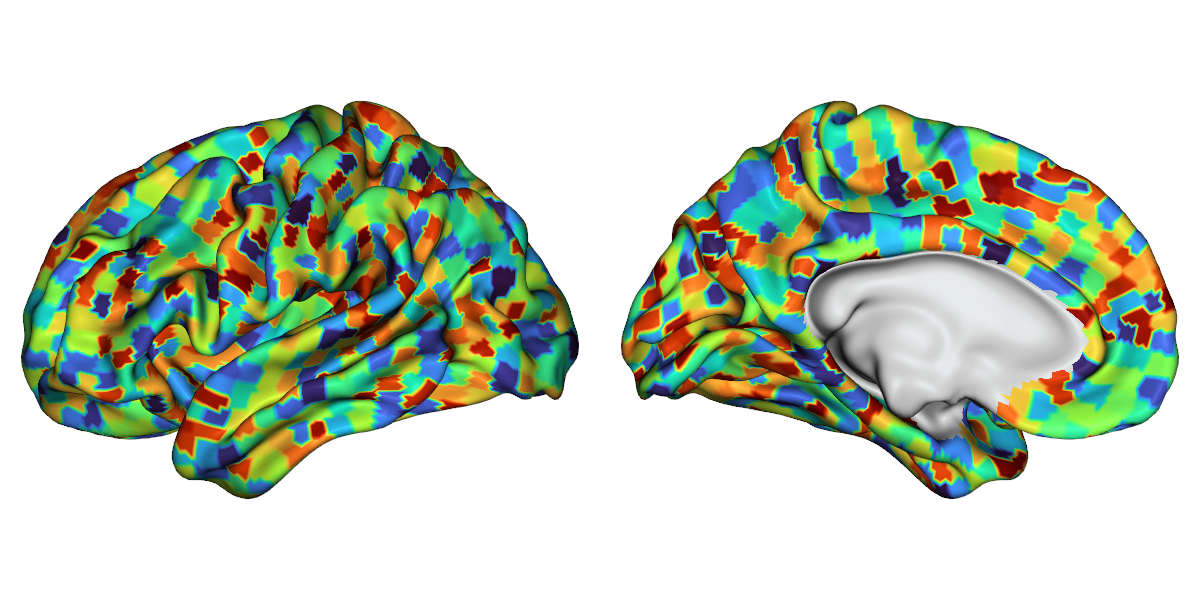

In [13]:
fig = plot_surf({'lh': surf}, size=(600,600), views=['lateral', 'medial'], zoom=1.2, data={'lh': unmask_data(parcellation, medmask)}, cmap='turbo')#, rois={'lh': unmask_data(parcellation, medmask)}, roi_outlines=True)
fig.show(jupyter_backend='static')

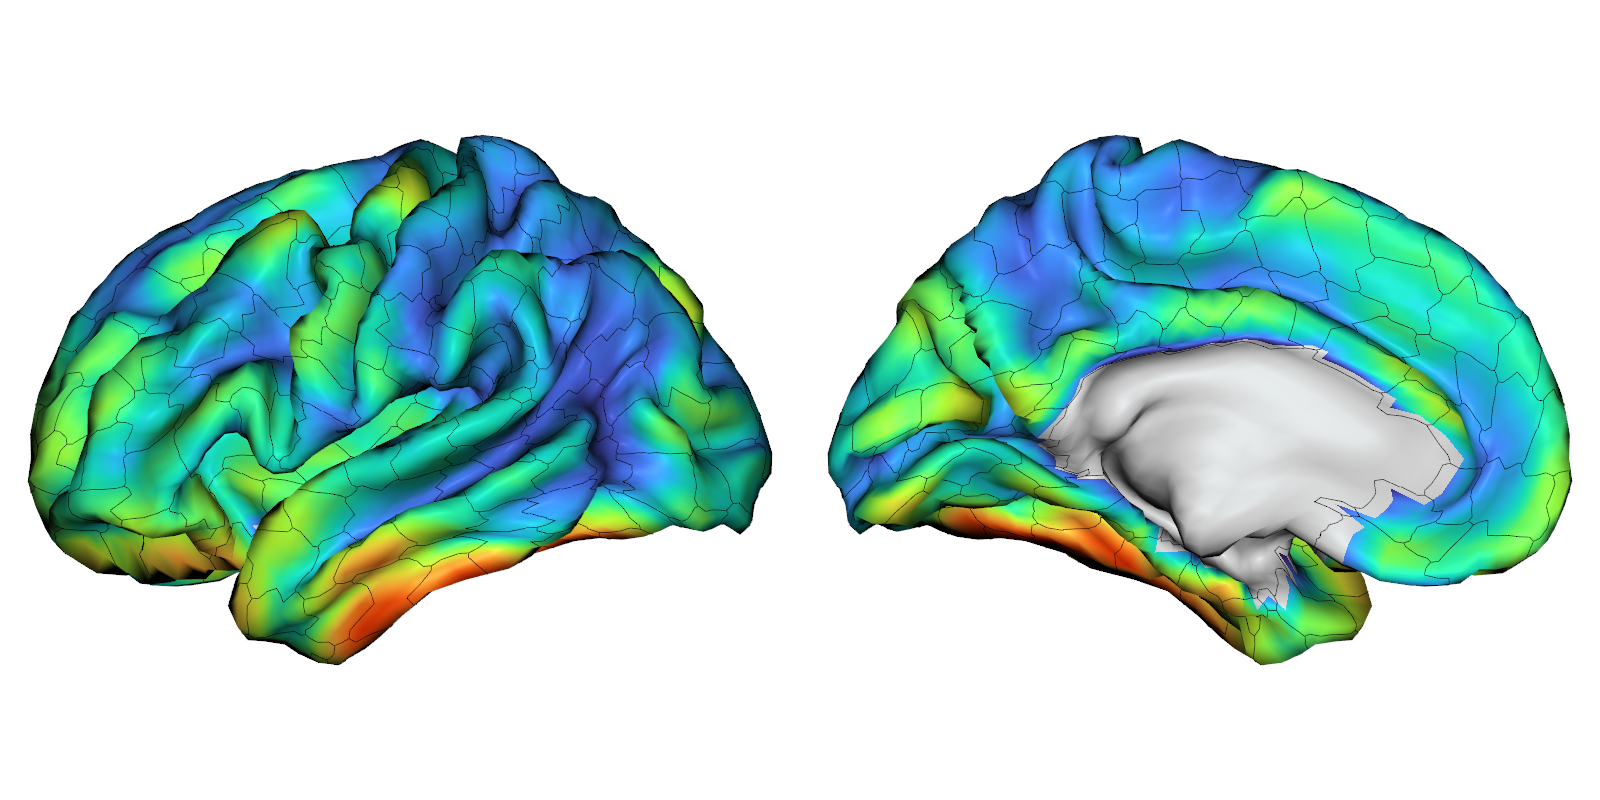

In [38]:
fig = plot_surf({'lh': surf}, {'lh': unmask_data(solver.mass.sum(axis=0).A1, medmask)}, size=(800,800), views=['lateral', 'medial'], zoom=1.2, rois={'lh': unmask_data(parcellation, medmask)}, roi_outlines=True)
fig.show(jupyter_backend='static')

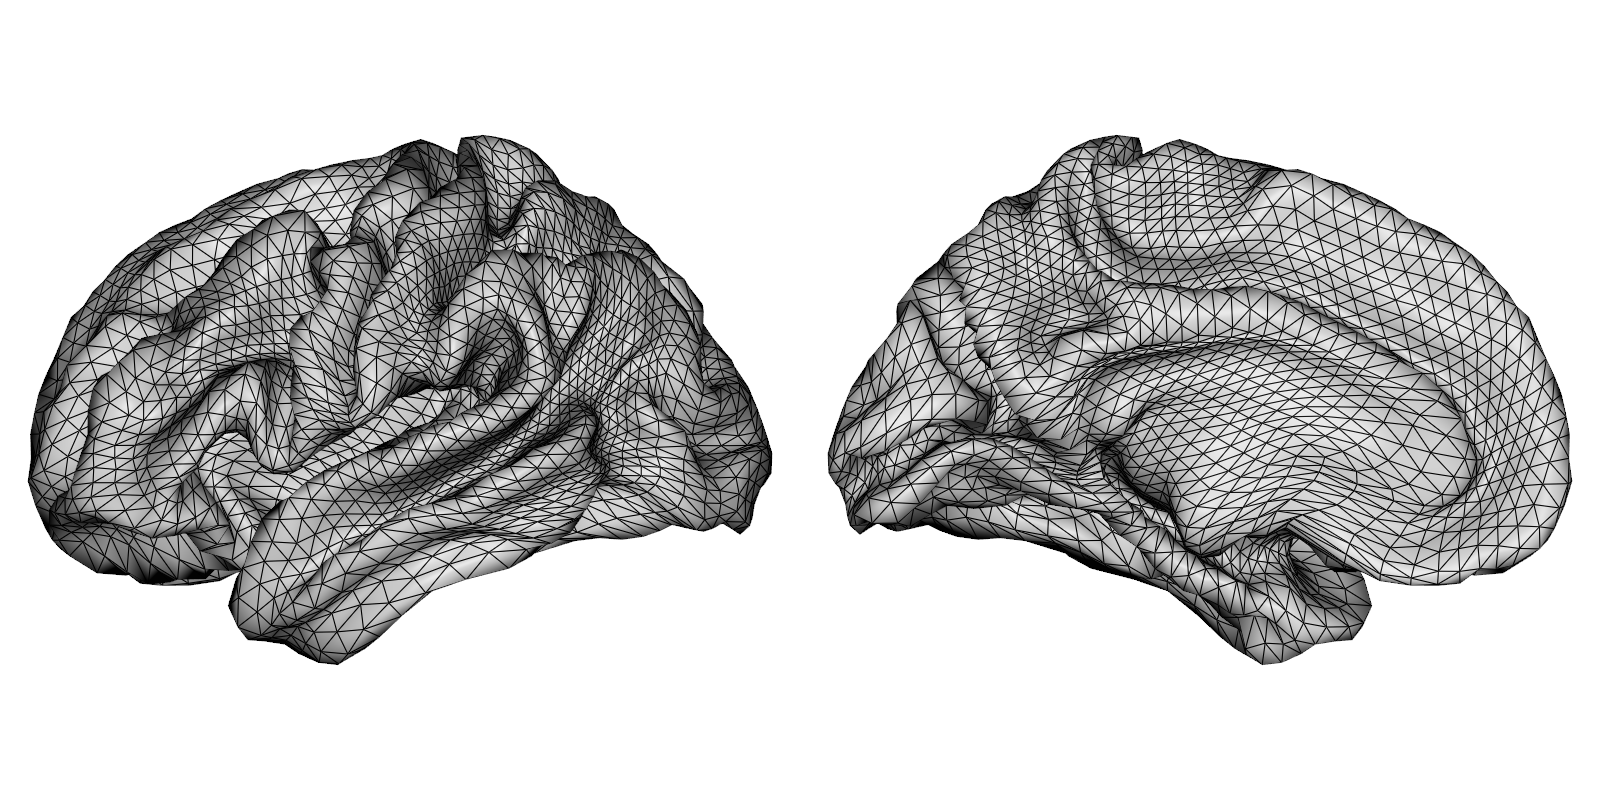

In [40]:
fig = plot_surf({'lh': surf}, size=(800,800), views=['lateral', 'medial'], zoom=1.2, mesh_edges=True)
fig.show(jupyter_backend='static')

In [14]:
# plot parcel areas by using mass matrix to compute area of each parcel
parcel_areas = np.zeros(parcellation.max())
for i in range(parcellation.max()):
    parcel_areas[i] = solver.mass[parcellation == i+1].sum()

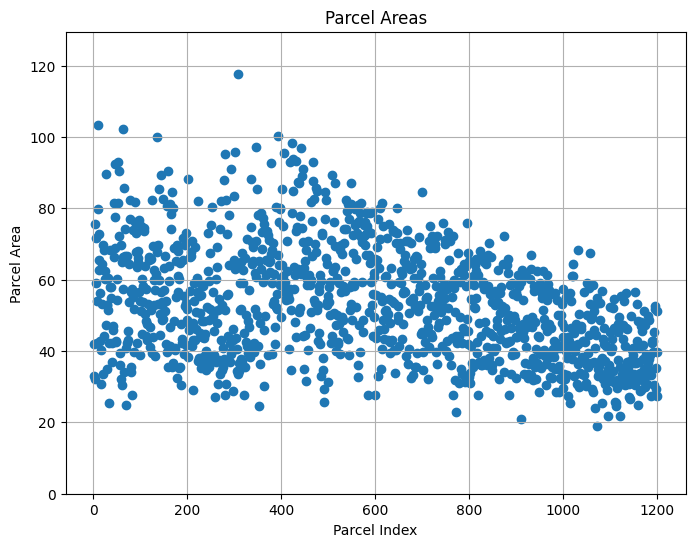

In [15]:
# scatter plot of parcel areas
plt.figure(figsize=(8, 6))
plt.scatter(range(1, parcellation.max()+1), parcel_areas)
plt.xlabel('Parcel Index')
plt.ylabel('Parcel Area')
plt.title('Parcel Areas')
plt.grid()
plt.ylim(0, np.max(parcel_areas)*1.1)
plt.show()

In [50]:
# calculate eigenmode 2 of single triangle
mesh = {'vertices': np.array([[100, 0, 0], [0, 200, 0], [0, 0, 300]]), 'faces': np.array([[0, 1, 2]])}
emode2 = EigenSolver(mesh).solve(2).emodes[:, 1]

In [51]:
fig = plot_surf({'lh': mesh}, {'lh': emode2}, cmap='seismic', size=(600,600))
fig.show()

Widget(value='<iframe src="http://localhost:56110/index.html?ui=P_0x25457829810_25&reconnect=auto" class="pyvi…